MODE 1 | Cen 1 | MC 1
MODE 1 | Cen 1 | MC 2
MODE 1 | Cen 1 | MC 3
MODE 1 | Cen 1 | MC 4
MODE 1 | Cen 1 | MC 5
MODE 1 | Cen 1 | MC 6
MODE 1 | Cen 1 | MC 7
MODE 1 | Cen 1 | MC 8
MODE 1 | Cen 1 | MC 9
MODE 1 | Cen 1 | MC 10
MODE 1 | Cen 1 | MC 11
MODE 1 | Cen 1 | MC 12
MODE 1 | Cen 1 | MC 13
MODE 1 | Cen 1 | MC 14
MODE 1 | Cen 1 | MC 15
MODE 1 | Cen 1 | MC 16
MODE 1 | Cen 1 | MC 17
MODE 1 | Cen 1 | MC 18
MODE 1 | Cen 1 | MC 19
MODE 1 | Cen 1 | MC 20
MODE 1 | Cen 1 | MC 21
MODE 1 | Cen 1 | MC 22
MODE 1 | Cen 1 | MC 23
MODE 1 | Cen 1 | MC 24
MODE 1 | Cen 1 | MC 25
MODE 1 | Cen 1 | MC 26
MODE 1 | Cen 1 | MC 27
MODE 1 | Cen 1 | MC 28
MODE 1 | Cen 1 | MC 29
MODE 1 | Cen 1 | MC 30
MODE 1 | Cen 1 | MC 31
MODE 1 | Cen 1 | MC 32
MODE 1 | Cen 1 | MC 33
MODE 1 | Cen 1 | MC 34
MODE 1 | Cen 1 | MC 35
MODE 1 | Cen 1 | MC 36
MODE 1 | Cen 1 | MC 37
MODE 1 | Cen 1 | MC 38
MODE 1 | Cen 1 | MC 39
MODE 1 | Cen 1 | MC 40
MODE 1 | Cen 1 | MC 41
MODE 1 | Cen 1 | MC 42
MODE 1 | Cen 1 | MC 43
MODE 1 | Cen 1 | MC 

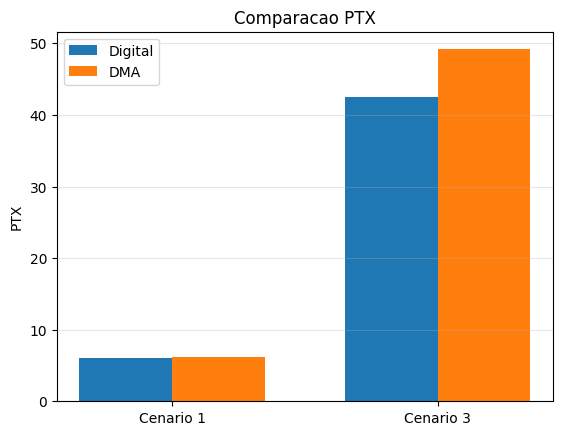

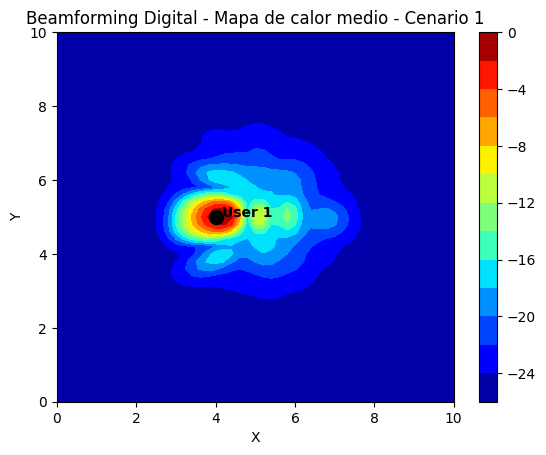

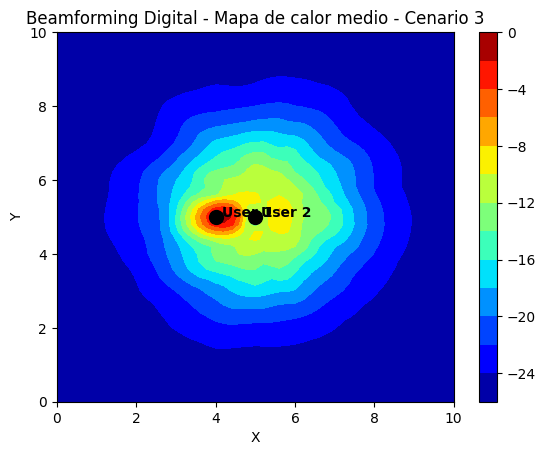

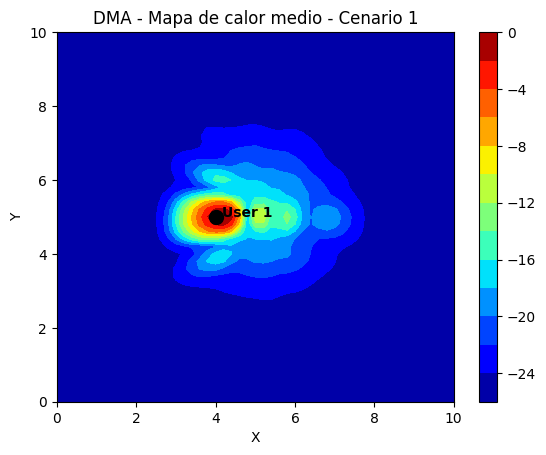

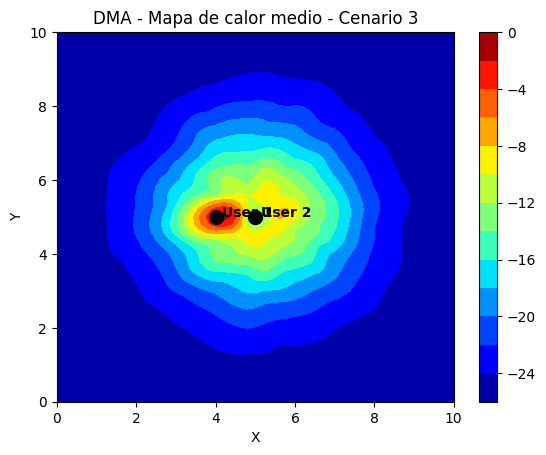

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
f_0 = 5e9
c0 = 299792458.0
lambda_ = c0 / f_0

boresight_gain = 2

Delta_EH = 500e-6
Delta_U = 50e-6

x_min, x_max = 0, 10
y_min, y_max = 0, 10
z_max = 3

cenarios = [1, 3]

# ============================================================
# GRADE PARA MAPA DE CALOR
# ============================================================
gradex = np.arange(x_min, x_max + 0.2, 0.2)
gradey = np.arange(y_min, y_max + 0.2, 0.2)
Nxg = len(gradex)
Nyg = len(gradey)

# ============================================================
# MONTE CARLO
# ============================================================
MC = 100

# ============================================================
# BAT ALGORITHM
# ============================================================
t_max = 200
n_bats = 100

# ============================================================
# RESULTADOS
# ============================================================
# MODE: 0 = Digital, 1 = DMA
PTX = np.zeros((2, len(cenarios), MC))
SUCCESS = np.zeros((2, len(cenarios), MC))

# mapa: (modo, cenário, x, y, mc)
PRX_MAP = np.zeros((2, len(cenarios), Nxg, Nyg, MC))


# ============================================================
# FUNÇÕES
# ============================================================
def H_DMA(f_0, L, x):
    c0 = 299792458.0
    lambda_ = c0 / f_0
    alpha = 0.5
    beta = 2 * np.pi / lambda_
    return np.exp(-x * (alpha + 1j * beta))


def Do_Channels(Y, X, boresight_gain, lambda_):
    """
    Y: posições dos elementos da antena, shape (N,3)
    X: posições dos usuários/pontos, shape (M,3)
    saída: channel_vec com shape (N,M)
    """
    Y = np.atleast_2d(Y)
    X = np.atleast_2d(X)

    N = Y.shape[0]
    M = X.shape[0]
    channel_vec = np.zeros((N, M), dtype=complex)

    for i in range(N):
        for m in range(M):
            d = np.linalg.norm(Y[i, :] - X[m, :])
            dz = abs(Y[i, 2] - X[m, 2])
            gain = (dz / d) ** boresight_gain
            channel_vec[i, m] = gain * (lambda_ / (4 * np.pi * d)) * np.exp(-1j * 2 * np.pi * d / lambda_)

    return channel_vec


# ============================================================
# LOOP PRINCIPAL
# MATLAB: MODE = 1:2
# Python: MODE = 0:1  -> 0=digital, 1=DMA
# ============================================================
for MODE in range(2):

    for c, cenario in enumerate(cenarios):

        for mc in range(MC):

            # MATLAB: rng(mc) com mc = 1..MC
            np.random.seed(mc + 1)

            # ========================================================
            # USUÁRIOS
            # ========================================================
            if cenario == 1:
                k_loc = np.array([[4, 5, 1]], dtype=float)
            else:
                k_loc = np.array([[4, 5, 1],
                                  [5, 5, 1]], dtype=float)

            # ========================================================
            # ANTENA
            # ========================================================
            L = 0.2
            DMA_WG_dist = lambda_ / 2
            DMA_element_dist = lambda_ / 5

            RFC_num = int(np.floor(L / DMA_WG_dist))
            passive_num = int(np.floor(L / DMA_element_dist))
            N = RFC_num * passive_num

            DMA_loc = np.array([5, 5, z_max], dtype=float)

            DMA_element_loc = np.zeros((N, 3), dtype=float)
            for i in range(RFC_num):
                for j in range(passive_num):
                    idx = i * passive_num + j
                    # MATLAB:
                    # [DMA_loc(1) + j*DMA_element_dist, DMA_loc(2) + i*DMA_WG_dist, DMA_loc(3)]
                    DMA_element_loc[idx, :] = np.array([
                        DMA_loc[0] + (j + 1) * DMA_element_dist,
                        DMA_loc[1] + (i + 1) * DMA_WG_dist,
                        DMA_loc[2]
                    ])

            # ========================================================
            # CANAL DOS USUÁRIOS
            # MATLAB: kk_loc = [k_loc(:,2) k_loc(:,1) k_loc(:,3)];
            # ========================================================
            kk_loc = np.column_stack((k_loc[:, 1], k_loc[:, 0], k_loc[:, 2]))
            channel_vec = Do_Channels(DMA_element_loc, kk_loc, boresight_gain, lambda_)

            # ========================================================
            # MATRIZ H (DMA)
            # ========================================================
            H = np.zeros((N, N), dtype=complex)
            for i in range(RFC_num):
                for l in range(passive_num):
                    idx = i * passive_num + l
                    # MATLAB usa (l-1)*DMA_element_dist
                    H[idx, idx] = H_DMA(f_0, L, l * DMA_element_dist)

            # ========================================================
            # BA INIT
            # MATLAB: SOL = randn(N,1,n_bats) + 1i*randn(N,1,n_bats);
            # ========================================================
            SOL = np.random.randn(N, 1, n_bats) + 1j * np.random.randn(N, 1, n_bats)
            erro = np.zeros(n_bats)

            for i in range(n_bats):
                w = SOL[:, :, i]
                if MODE == 0:  # digital
                    erro[i] = np.sum(np.abs(w) ** 2)
                else:          # DMA
                    erro[i] = np.sum(np.abs(H @ w) ** 2)

            idx_best = np.argmin(erro)
            best_val = erro[idx_best]
            best = SOL[:, :, idx_best].copy()

            # ========================================================
            # BAT ALGORITHM
            # ========================================================
            for t in range(t_max):
                for b in range(n_bats):

                    w_new = (
                        SOL[:, :, b]
                        + 0.1 * (best - SOL[:, :, b])
                        + 0.05 * (np.random.randn(N, 1) + 1j * np.random.randn(N, 1))
                    )

                    # ====================================================
                    # DIGITAL
                    # ====================================================
                    if MODE == 0:
                        Ptx = np.sum(np.abs(w_new) ** 2)
                        P1 = np.abs(np.conj(channel_vec[:, 0]).T @ w_new[:, 0]) ** 2

                        if cenario == 1:
                            ok = (P1 >= Delta_EH)
                        else:
                            P2 = np.abs(np.conj(channel_vec[:, 1]).T @ w_new[:, 0]) ** 2
                            ok = (P1 >= Delta_EH) and (P2 <= Delta_U)

                    # ====================================================
                    # DMA
                    # ====================================================
                    else:
                        Hw = H @ w_new
                        Ptx = np.sum(np.abs(Hw) ** 2)
                        P1 = np.abs(np.conj(channel_vec[:, 0]).T @ Hw[:, 0]) ** 2

                        if cenario == 1:
                            ok = (P1 >= Delta_EH)
                        else:
                            P2 = np.abs(np.conj(channel_vec[:, 1]).T @ Hw[:, 0]) ** 2
                            ok = (P1 >= Delta_EH) and (P2 <= Delta_U)

                    if ok and (Ptx < erro[b]):
                        SOL[:, :, b] = w_new
                        erro[b] = Ptx

                        if Ptx < best_val:
                            best = w_new.copy()
                            best_val = Ptx

            # ========================================================
            # RESULTADOS
            # ========================================================
            PTX[MODE, c, mc] = best_val

            if MODE == 0:
                final_vec = best
            else:
                final_vec = H @ best

            if cenario == 1:
                SUCCESS[MODE, c, mc] = (
                    np.abs(np.conj(channel_vec[:, 0]).T @ final_vec[:, 0]) ** 2 >= Delta_EH
                )
            else:
                SUCCESS[MODE, c, mc] = (
                    (np.abs(np.conj(channel_vec[:, 0]).T @ final_vec[:, 0]) ** 2 >= Delta_EH)
                    and
                    (np.abs(np.conj(channel_vec[:, 1]).T @ final_vec[:, 0]) ** 2 <= Delta_U)
                )

            # ========================================================
            # MAPA DE CALOR
            # ========================================================
            PRX = np.zeros((Nxg, Nyg))

            for ix in range(Nxg):
                for iy in range(Nyg):
                    # MATLAB: test_point = [gradey(iy), gradex(ix), 1];
                    test_point = np.array([gradey[iy], gradex[ix], 1.0])
                    ctest = Do_Channels(DMA_element_loc, test_point, boresight_gain, lambda_)

                    PRX[ix, iy] = np.abs(np.conj(ctest[:, 0]).T @ final_vec[:, 0]) ** 2

            # normalização em dB
            PRX = PRX / np.max(PRX)
            PRX = 10 * np.log10(PRX)
            PRX[PRX < -25] = -25

            PRX_MAP[MODE, c, :, :, mc] = PRX

            print(f"MODE {MODE+1} | Cen {cenario} | MC {mc+1}")

# ============================================================
# RESULTADOS
# ============================================================
print("\n====== RESULTADOS ======\n")

for MODE in range(2):
    if MODE == 0:
        print("--- DIGITAL ---")
    else:
        print("--- DMA ---")

    for c, cenario in enumerate(cenarios):
        print(f"Cenario {cenario}:")
        print(f"PTX medio = {np.mean(PTX[MODE, c, :]):.2e}")
        print(f"Sucesso = {100 * np.mean(SUCCESS[MODE, c, :]):.2f} %")

# ============================================================
# GRÁFICO DE COMPARAÇÃO
# ============================================================
bar_data = np.array([
    [np.mean(PTX[0, 0, :]), np.mean(PTX[1, 0, :])],  # C1
    [np.mean(PTX[0, 1, :]), np.mean(PTX[1, 1, :])]   # C3
])

plt.figure()
x = np.arange(bar_data.shape[0])
width = 0.35

plt.bar(x - width/2, bar_data[:, 0], width, label='Digital')
plt.bar(x + width/2, bar_data[:, 1], width, label='DMA')
plt.xticks(x, ['Cenario 1', 'Cenario 3'])
plt.ylabel('PTX')
plt.title('Comparacao PTX')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# ============================================================
# MAPAS DE CALOR MÉDIOS
# ============================================================
for MODE in range(2):
    for c in range(len(cenarios)):

        PRX_mean = np.mean(PRX_MAP[MODE, c, :, :, :], axis=2)

        plt.figure(facecolor='w')
        contour = plt.contourf(gradex, gradey, PRX_mean.T, levels=12)
        plt.colorbar(contour)
        plt.set_cmap('jet')
        plt.xlabel('X')
        plt.ylabel('Y')

        if MODE == 0:
            metodo = 'Beamforming Digital'
        else:
            metodo = 'DMA'

        plt.title(f'{metodo} - Mapa de calor medio - Cenario {cenarios[c]}')

        if cenarios[c] == 1:
            k_loc = np.array([[4, 5, 1]], dtype=float)
        else:
            k_loc = np.array([[4, 5, 1],
                              [5, 5, 1]], dtype=float)

        plt.plot(k_loc[:, 0], k_loc[:, 1], 'ko', markersize=10)

        for u in range(k_loc.shape[0]):
            plt.text(
                k_loc[u, 0] + 0.15,
                k_loc[u, 1],
                f'User {u+1}',
                color='k',
                fontweight='bold'
            )

        plt.show()